# Validation results file "Database_Generation_MB.py"

In [3]:
import numpy as np
np.infty = np.inf
import sys
import numpy as np
import cantera as ct
import matplotlib.pyplot as plt
import itertools
import scipy.integrate
import ctypes as xt
import os
from ideal_reactor_models import customESC_BM
from ideal_reactor_models import customPFR
import pandas as pd
import csv

In [2]:
def CRACKSIM_rates_DLL(gas):
    # CRACKSIM_rates_C call the rates function in CRACKSIM.DLL
    # concentration bassis 

    # initialize temperature and concentrations
    T= gas.T     # [K]
    C_point=gas.concentrations #[mol/l]
    status = 0              

    # copy values to Ctypes to be used as arguements for the Fortran DLL
    C_point= gas.concentrations.ctypes
    T_point = xt.byref(xt.c_double(T)) 
    status = xt.pointer(xt.c_int(status))


    # initalize a ctype pointer to be used as storage for the calculated rates 
    R_point = (xt.c_double*gas.n_species)()     # mol/(s.L)
  
    _ = fortlib.NetRates_C(T_point,C_point,R_point,status)  # function call of CRACKSIM DLL
    
    # convert Ctype to python array
    rates=np.ctypeslib.as_array(R_point)
    rates=rates         #[mol/l/s]
    return rates
    #return rates

In [3]:
# initialize kinetics 
fortlib = xt.CDLL(r"C:\Users\Louis\OneDrive\Bureaublad\ugent\Master2\Thesis\Code_Turboreactor\SA_CRACKSIM.dll") #change this to the location where you stored the dll
status = 0
option = (xt.c_int*20)()
# please note that in python arrays possitions starts counting from 0 
            # option(1) : 
            #      0 use full network
            #      1 use reduced network based on compossition file 
            #      2 use only betanetwork
option[0]= 1
status = xt.pointer(xt.c_int(status)) # setup the pointer to the correct data structure
_ = fortlib.Initialise_CRACKSIM(status,option)            # call the function
status = status[0]
if status==1:
    print("Kinetics and Thermo were read succesfuly")
else:
    print("Errors while reading Kinetics and Thermo")

Kinetics and Thermo were read succesfuly


## Error NASA-polynomes

In [5]:
#Included to suppress the error warnings related to the NASA polynomes
ct.suppress_thermo_warnings()       # currently an issue with Nasapolynomials 
# convert the chem.inp file created by the DLL to yaml file

!ck2yaml --input=chem.inp --transport=transport_chemkin.DAT --permissive > C2KYAML_log.txt

C:\Users\Louis\anacondadownload\envs\cantera-env\lib\site-packages\cantera\ck2yaml.py:2344: UserWarning: NasaPoly2::validate: 
For species CO, discontinuity in h/RT detected at Tmid = 1400
	Value computed using low-temperature polynomial:  -6.48615241904762
	Value computed using high-temperature polynomial: -6.431806107428571

  gas = Solution(out_name)
C:\Users\Louis\anacondadownload\envs\cantera-env\lib\site-packages\cantera\ck2yaml.py:2344: UserWarning: NasaPoly2::validate: 
For species CO2, discontinuity in h/RT detected at Tmid = 1400
	Value computed using low-temperature polynomial:  -29.0113435047619
	Value computed using high-temperature polynomial: -28.977686331657146

  gas = Solution(out_name)
C:\Users\Louis\anacondadownload\envs\cantera-env\lib\site-packages\cantera\ck2yaml.py:2344: UserWarning: NasaPoly2::validate: 
For species NEOC5, discontinuity in cp/R detected at Tmid = 1400
	Value computed using low-temperature polynomial:  42.78292259039995
	Value computed using hig

## Coninue code

In [7]:
reac_mech_DLL = 'chem.yaml'
gas_id = 'gas'
gas = ct.Solution(reac_mech_DLL)
print('Gas mechanism contains {} species and {} reactions'.format(gas.n_species, gas.n_reactions))

Gas mechanism contains 239 species and 0 reactions


## Inlezen Database_Validation.csv

In [43]:
dataframe = []
with open('Database_Validation3.csv','r') as infile:
    for rij in csv.reader(infile,delimiter=','):
        dataframe.append(rij)

In [45]:
print(len(dataframe))

202


In [47]:
for i in range(len(dataframe[0])):
    if dataframe[0][i] == 'CaseID':
        indexID = i
    if dataframe[0][i] == 'T [K]':
        indexT = i
    if dataframe[0][i] == 'P [Pa]':
        indexP = i
    if dataframe[0][i] == 'Mass flow [kg/s]':
        indexmdot = i
    if dataframe[0][i] == 'S Energy [J/s/m3]':
        indexSE = i
    if dataframe[0][i] == 'Y_C2H6':
        indexC2H6 = i
    if dataframe[0][i] == 'mdot [kg/s]':
        indexmdot2 = i
    if dataframe[0][i] == 'shape':
        indexshape = i
    if dataframe[0][i] == 'Heat input [W/m^2]':
        indexHI = i
    if dataframe[0][i] == 'H_peak [W/m^2]':
        indexHI2 = i
    if dataframe[0][i] == 'X_H2O':
        indexX = i
    if dataframe[0][i] == 'z [m]':
        indexZ = i
    if dataframe[0][i] == 'Y_C2H4':
        indexC2H4 = i
    if dataframe[0][i] == 'cp_mass [J/kg/K]':
        indexCp = i
    if dataframe[0][i] == 'T_in [K]':
        indexTin = i
    if dataframe[0][i] == 'W_mean [kg/kmol]':
        indexW = i
print(indexC2H6)

2


In [49]:
case_uniform = []
for i in range(len(dataframe)):
    if dataframe[i][indexshape] == 'uniform':
        case_uniform.append(dataframe[i])

In [53]:
print(dataframe[0][indexC2H4])

Y_C2H4


In [14]:
mdot = []
Tprof = []
c2h4 = []
c2h6 = []
SE = []
cp = []
T_in = []
W = []
axial_dist = []
for i in range(len(case_uniform)):
    axial_dist.append(float(case_uniform[i][indexZ]))
    mdot.append(float(case_uniform[i][indexmdot]))
    c2h4.append(float(case_uniform[i][indexC2H4]))
    c2h6.append(float(case_uniform[i][indexC2H6]))
    Tprof.append(float(case_uniform[i][indexT]))
    SE.append(float(case_uniform[i][indexSE]))
    cp.append(float(case_uniform[i][indexCp]))
    T_in.append(float(case_uniform[i][indexTin]))
    W.append(float(case_uniform[i][indexW]))
#print((axial_dist))

In [15]:
print((case_uniform[10][indexHI],case_uniform[10][indexHI2]),(case_uniform[100][indexmdot],case_uniform[100][indexmdot2]))
# Heat input en mass flow worden dubbel opgeslaan, mag aangepast worden om opslag van de uiteindelijke file te verkleinen

('100000.0', '100000.0') ('1.6212435245483843', '1.6212435245483843')


## Generation validation data

In [5]:
massflow = 1.6212435245483843 #float(case_uniform[0][indexmdot])
H_input = 100000#float(case_uniform[0][indexHI])
diam = 0.5
T_in = 550 + 273.15 #float(case_uniform[0][indexT])
P_in = 2e5 #float(case_uniform[0][indexP])
X_H2O = 0.3 #float(case_uniform[0][indexX])
length = 8.5 #float(case_uniform[-1][indexZ])
aantal = 200 #len(axial_dist)
hf = ct.Func1(lambda z: np.interp(z,[0,length],[H_input,H_input]))
print(hf(5))

100000.0


In [20]:
PFR_calc = customPFR(reac_mech_DLL, gas_id, massflow, diam, CRACKSIM_rates_DLL, energy_type = 'heat-flux-profile', heat_flux = hf, U = None, Tr = None, friction_factors = None)

In [23]:
PFR_calc.gas.TPY = T_in, P_in, {'C2H6':(1-X_H2O), 'H2O':X_H2O}

In [24]:
states, rates, enth = PFR_calc.solve(length,aantal)

In [39]:
print(states)


           T         D           H2          CH4      C2H6  ... energy_source_term mass_flow  Cp_mass Molecular_weight
0    823.150  0.731809  0.00000e+00  0.00000e+00  0.700000  ...       -1.17372e+00   1.62124  3232.67          25.0427
1    824.423  0.730679  3.81155e-10  5.23821e-10  0.700000  ...       -1.20781e+01   1.62124  3235.35          25.0427
2    825.695  0.729553  1.61969e-09  1.09862e-09  0.700000  ...       -2.49029e+01   1.62124  3238.02          25.0427
3    826.967  0.728432  3.84107e-09  1.72308e-09  0.700000  ...       -3.95004e+01   1.62124  3240.69          25.0427
4    828.237  0.727315  7.17595e-09  2.40126e-09  0.700000  ...       -5.59330e+01   1.62124  3243.35          25.0427
..       ...       ...          ...          ...       ...  ...                ...       ...      ...              ...
196  995.732  0.582734  3.07681e-03  2.68999e-04  0.653428  ...       -6.47100e+05   1.62124  3563.59          24.1222
197  995.952  0.582280  3.12358e-03  2.74421e-04

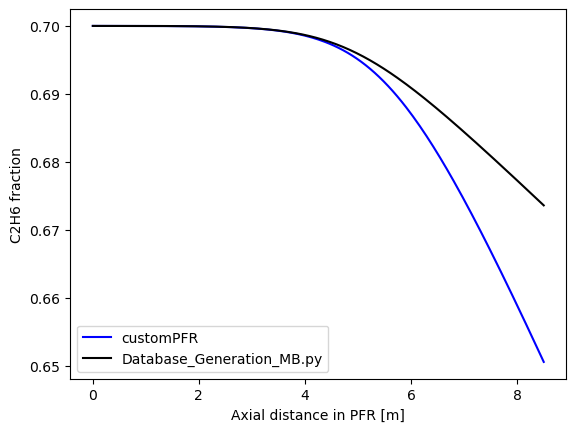

In [41]:
plt.figure()
plt.plot(axial_dist,states.C2H6,color='blue',label='customPFR')
plt.plot(axial_dist,c2h6,color='black',label='Database_Generation_MB.py')
plt.xlabel('Axial distance in PFR [m]')
plt.ylabel('C2H6 fraction')
plt.legend()
plt.show()

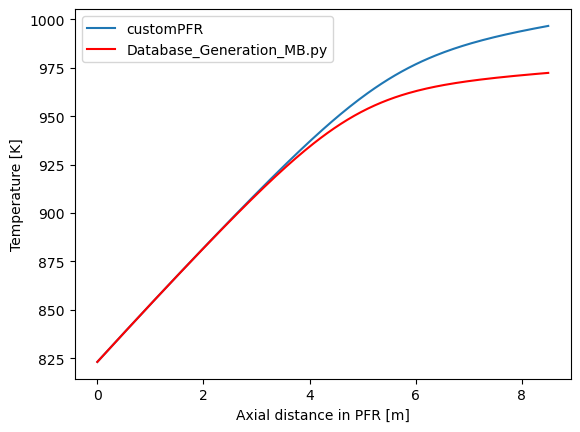

In [67]:
plt.figure()
plt.plot(axial_dist, states.T,label='customPFR')
plt.plot(axial_dist, Tprof,color='red',label='Database_Generation_MB.py')
plt.xlabel('Axial distance in PFR [m]')
plt.ylabel('Temperature [K]')
plt.legend()
plt.show()

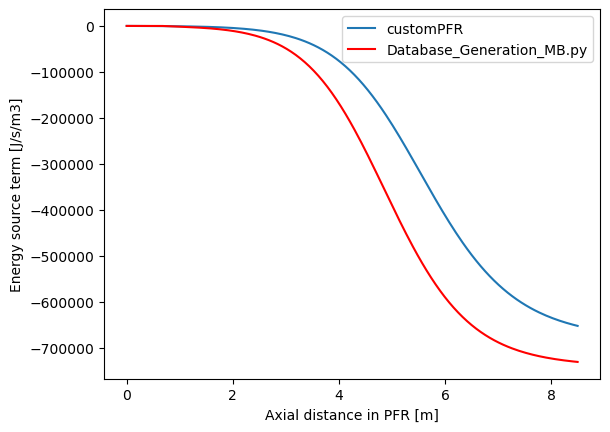

In [68]:
plt.figure()
plt.plot(axial_dist,states.energy_source_term,label='customPFR')
plt.plot(axial_dist,SE,color='red',label='Database_Generation_MB.py')
plt.legend()
plt.xlabel('Axial distance in PFR [m]')
plt.ylabel('Energy source term [J/s/m3]')
plt.show()

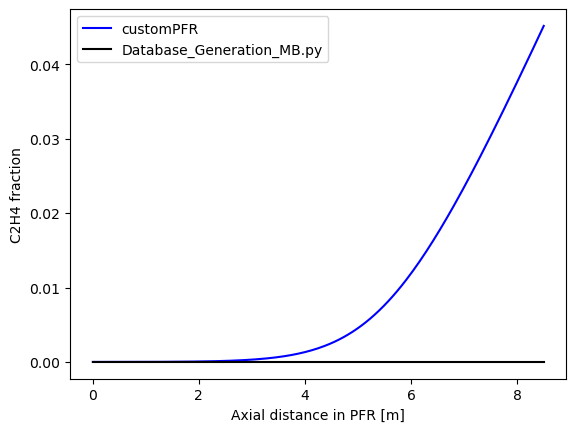

In [69]:
plt.figure()
plt.plot(axial_dist,states.C2H4,color='blue',label='customPFR')
plt.plot(axial_dist,c2h4,color='black',label='Database_Generation_MB.py')
plt.xlabel('Axial distance in PFR [m]')
plt.ylabel('C2H4 fraction')
plt.legend()
plt.show()

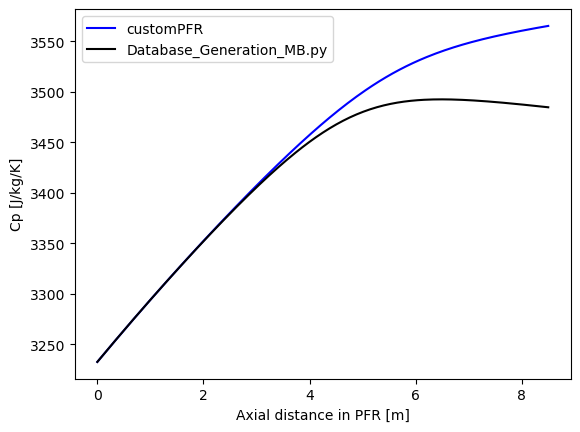

In [44]:
plt.figure()
plt.plot(axial_dist,states.Cp_mass,color='blue',label='customPFR')
plt.plot(axial_dist,cp,color='black',label='Database_Generation_MB.py')
plt.xlabel('Axial distance in PFR [m]')
plt.ylabel('Cp [J/kg/K]')
plt.legend()
plt.show()

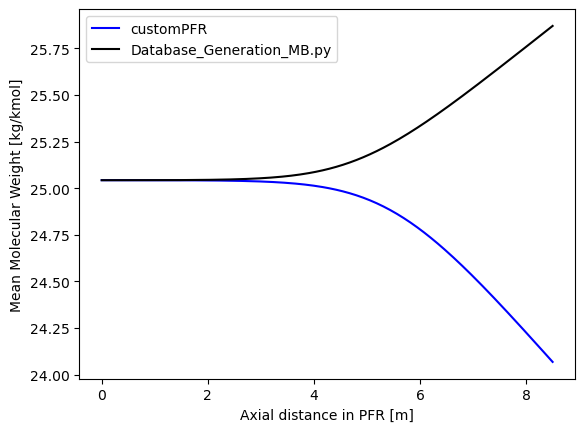

In [41]:
plt.figure()
plt.plot(axial_dist,states.Molecular_weight,color='blue',label='customPFR')
plt.plot(axial_dist,W,color='black',label='Database_Generation_MB.py')
plt.xlabel('Axial distance in PFR [m]')
plt.ylabel('Mean Molecular Weight [kg/kmol]')
plt.legend()
plt.show()